# 01b — Single-network walk-through (April globals)

Minimal step-by-step look at the April global aggregates. One cell per
scope: load → weight distribution → raw heatmaps → MP denoising (heatmaps)
→ percolation $P_\infty,\, E_\infty(\theta)$ → network drawing of the
strongest connections.

All plotting and numerics go through library functions — the notebook
is purely orchestration.

In [1]:
from __future__ import annotations

from pathlib import Path

import networkx as nx
import numpy as np

from multifunbrain.datasets.april import (
    DEFAULT_APRIL_ROOT,
    discover_april,
    gamma_for,
    label_for,
    load_entry,
)
from multifunbrain.preprocessing import (
    marchenko_pastur_denoise,
    prepare_correlation_matrix,
)
from multifunbrain.visualization.plotlib import (
    plot_correlation_matrix,
    plot_percolation_curve,
    plot_weight_distribution,
    plt,
)

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name and not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
APRIL_ROOT = REPO_ROOT / DEFAULT_APRIL_ROOT
GRID = (2, 5)  # rows = contrasts (co2, rest); cols = processing variants

print(f"repo:    {REPO_ROOT}")
print(f"data:    {APRIL_ROOT}")

repo:    /home/opisthofulax/Documents/research+/brain_network/multifun-brain
data:    /home/opisthofulax/Documents/research+/brain_network/multifun-brain/data/correlation_mat_april_data


## 1. Load the global matrices

Ten aggregates: 2 contrasts (`co2`, `rest`) × 5 processing variants
(`bpfBOLD`, `bpfVASO`, `MIRNoise_bold`, `optcom_bold`,
`optcomMIRDenoised_bold`). `prepare_correlation_matrix` drops NaN-marked
dead regions, symmetrises, clips to $[-1, 1]$, and zeros the diagonal.

In [2]:
entries = discover_april(APRIL_ROOT, levels=["global"])
print(f"discovered {len(entries)} global entries")

globals_data: dict[str, dict] = {}
for entry in entries:
    corr_prepared = prepare_correlation_matrix(load_entry(entry))
    globals_data[label_for(entry)] = {
        "entry": entry,
        "corr": corr_prepared,
        "gamma": gamma_for(entry),
    }

for label, rec in globals_data.items():
    print(f"{label:36s}  shape={rec['corr'].shape}  \u03b3={rec['gamma']:.3f}")

discovered 10 global entries
global/co2_MIRNoise_bold              shape=(100, 100)  γ=0.168
global/co2_bpfBOLD                    shape=(100, 100)  γ=0.226
global/co2_bpfVASO                    shape=(100, 100)  γ=0.226
global/co2_optcomMIRDenoised_bold     shape=(100, 100)  γ=0.168
global/co2_optcom_bold                shape=(100, 100)  γ=0.168
global/rest_MIRNoise_bold             shape=(100, 100)  γ=0.168
global/rest_bpfBOLD                   shape=(100, 100)  γ=0.226
global/rest_bpfVASO                   shape=(100, 100)  γ=0.226
global/rest_optcomMIRDenoised_bold    shape=(100, 100)  γ=0.168
global/rest_optcom_bold               shape=(100, 100)  γ=0.168


## 2. Edge-weight distributions

Off-diagonal Pearson weights $\{C_{ij}\}_{i<j}$ split into positive
(blue) and negative (red) lobes. Reveals the matrix's signed structure
and how strongly it is biased toward positive correlations.

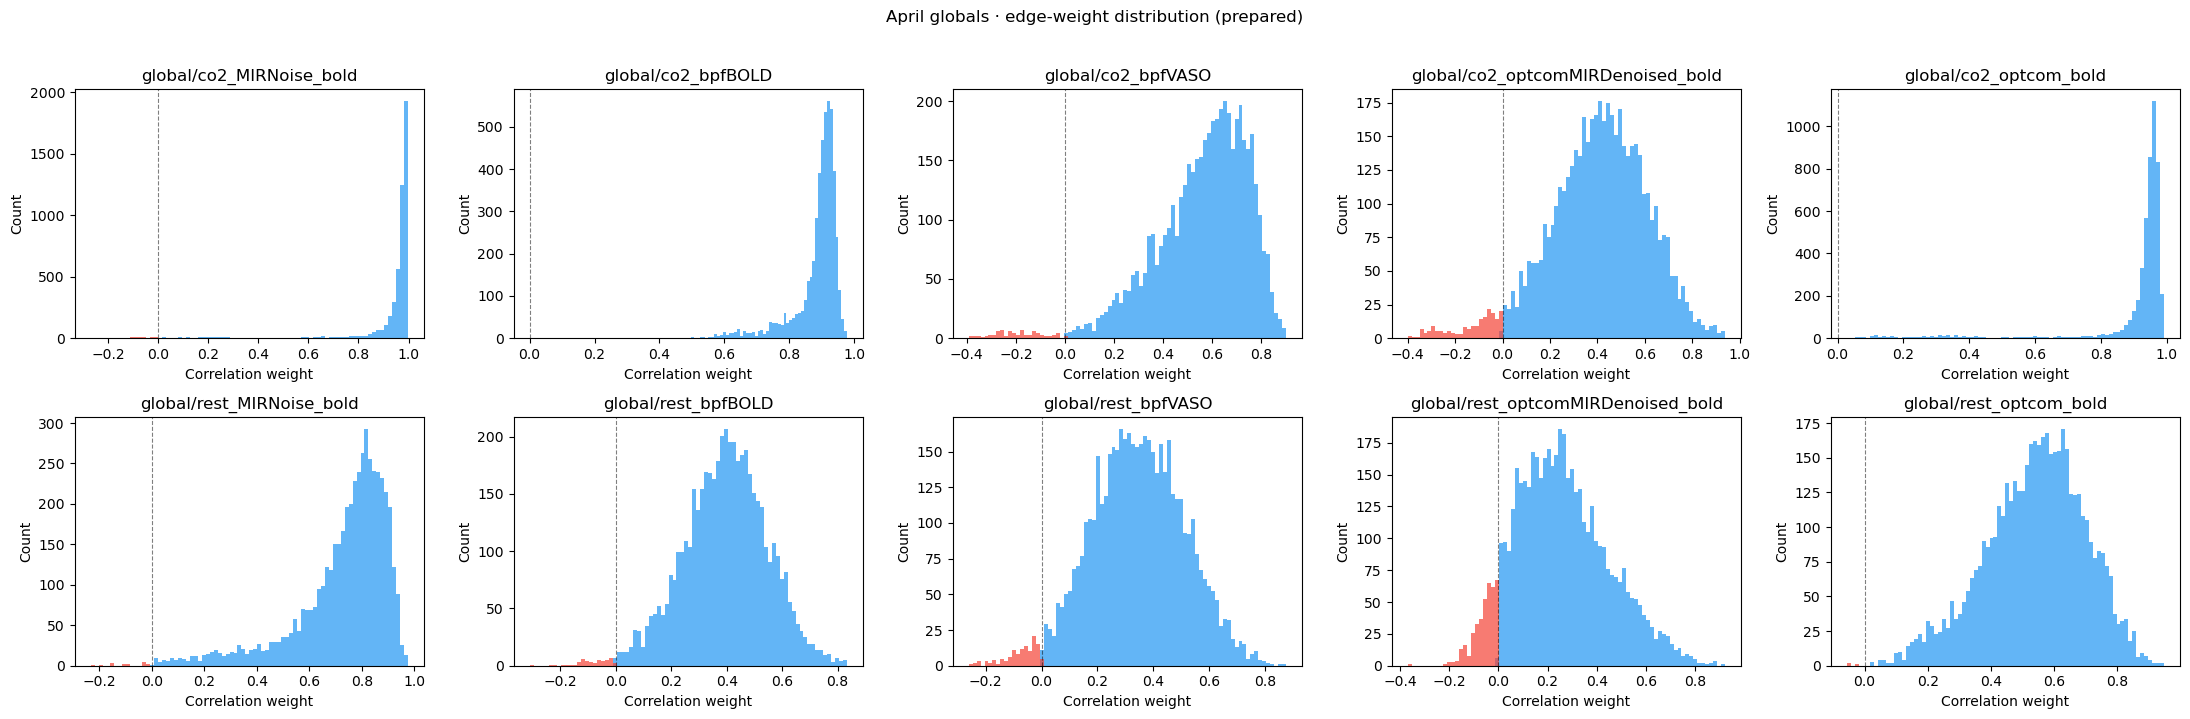

In [3]:
fig, axes = plt.subplots(*GRID, figsize=(22, 7), squeeze=False)
for ax, (label, rec) in zip(axes.ravel(), globals_data.items()):
    triu = np.triu_indices_from(rec["corr"], k=1)
    w = rec["corr"][triu]
    plot_weight_distribution(
        {"positive_weights": w[w > 0], "negative_weights": w[w < 0]},
        ax=ax,
        title=label,
        legend=False,
    )
fig.suptitle("April globals · edge-weight distribution (prepared)", y=1.02)
fig.tight_layout()
plt.show()

## 3. Prepared correlation matrices (before MP)

Heatmaps of the raw signed Pearson matrices after `prepare_correlation_matrix`
only — no denoising yet. Same diverging colour scale across panels for
side-by-side comparison.

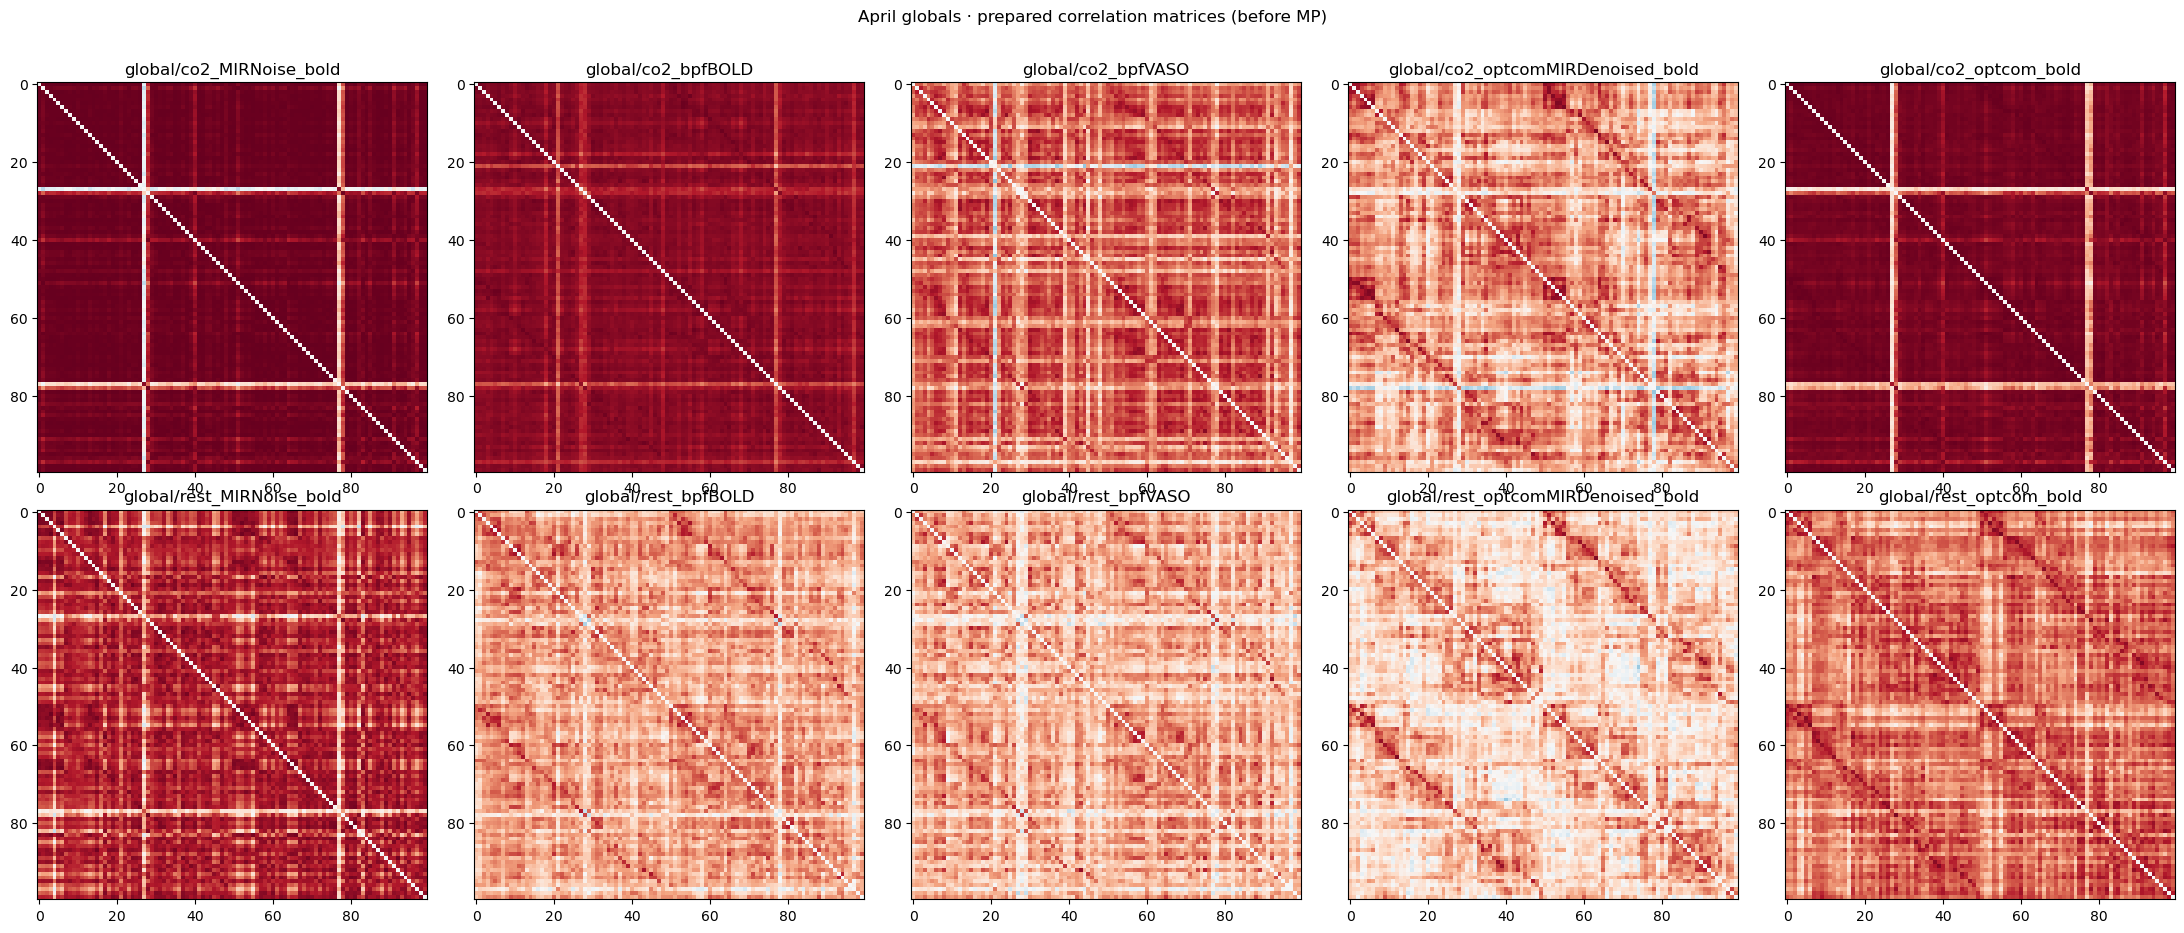

In [4]:
vmax_raw = float(max(np.abs(rec["corr"]).max() for rec in globals_data.values()))

fig, axes = plt.subplots(*GRID, figsize=(22, 9), squeeze=False)
for ax, (label, rec) in zip(axes.ravel(), globals_data.items()):
    plot_correlation_matrix(rec["corr"], ax=ax, title=label, vmax=vmax_raw, colorbar=False)
fig.suptitle("April globals · prepared correlation matrices (before MP)", y=1.02)
fig.tight_layout()
plt.show()

## 4. Marchenko–Pastur denoising and re-plot

For each matrix compute $\gamma = N/T$ from the processing variant, then
eigen-shrink with `marchenko_pastur_denoise`: eigenvalues inside the
noise bulk are clipped up to $\lambda_+ = (1 + \sqrt{\gamma})^{2}$; signal
modes ($\lambda > \lambda_+$) are preserved untouched. Heatmaps below
use the same diverging colour scale across panels.

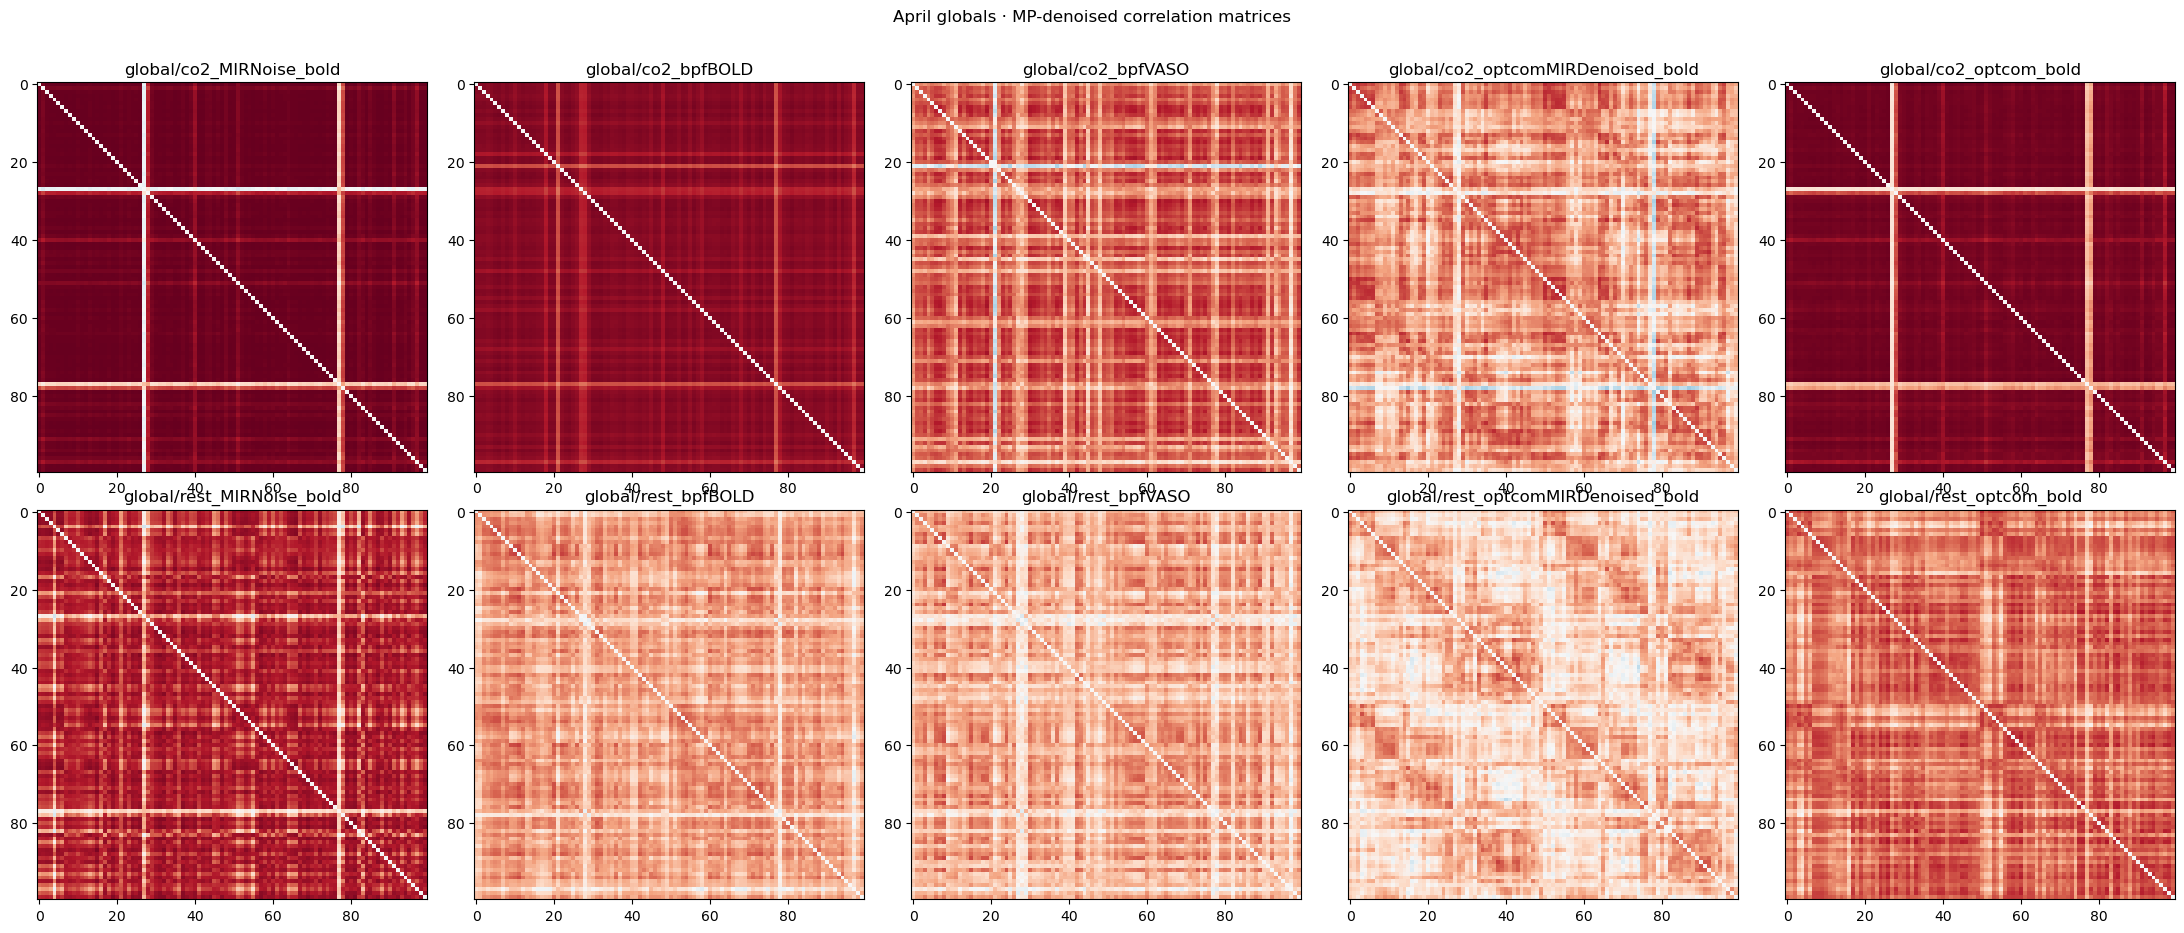

In [5]:
for rec in globals_data.values():
    rec["corr_mp"] = marchenko_pastur_denoise(rec["corr"], gamma=rec["gamma"])

vmax_mp = float(max(np.abs(rec["corr_mp"]).max() for rec in globals_data.values()))

fig, axes = plt.subplots(*GRID, figsize=(22, 9), squeeze=False)
for ax, (label, rec) in zip(axes.ravel(), globals_data.items()):
    plot_correlation_matrix(rec["corr_mp"], ax=ax, title=label, vmax=vmax_mp, colorbar=False)
fig.suptitle("April globals · MP-denoised correlation matrices", y=1.02)
fig.tight_layout()
plt.show()

## 5. Percolation $P_\infty(\theta)$ and $E_\infty(\theta)$ on the MP-cleaned matrices

For each threshold $\theta$, keep edges with $|w_{ij}| \geq \theta$ and
record:

- $P_\infty(\theta)$: fraction of nodes in the giant connected component.
- $E_\infty(\theta)$: surviving edge fraction $|E|\,/\,\binom{N}{2}$.

A staircase in $P_\infty$ would indicate functional sub-modules
detaching at different strengths; a single sharp drop indicates a
dense, random-graph-like topology with no weight gap.

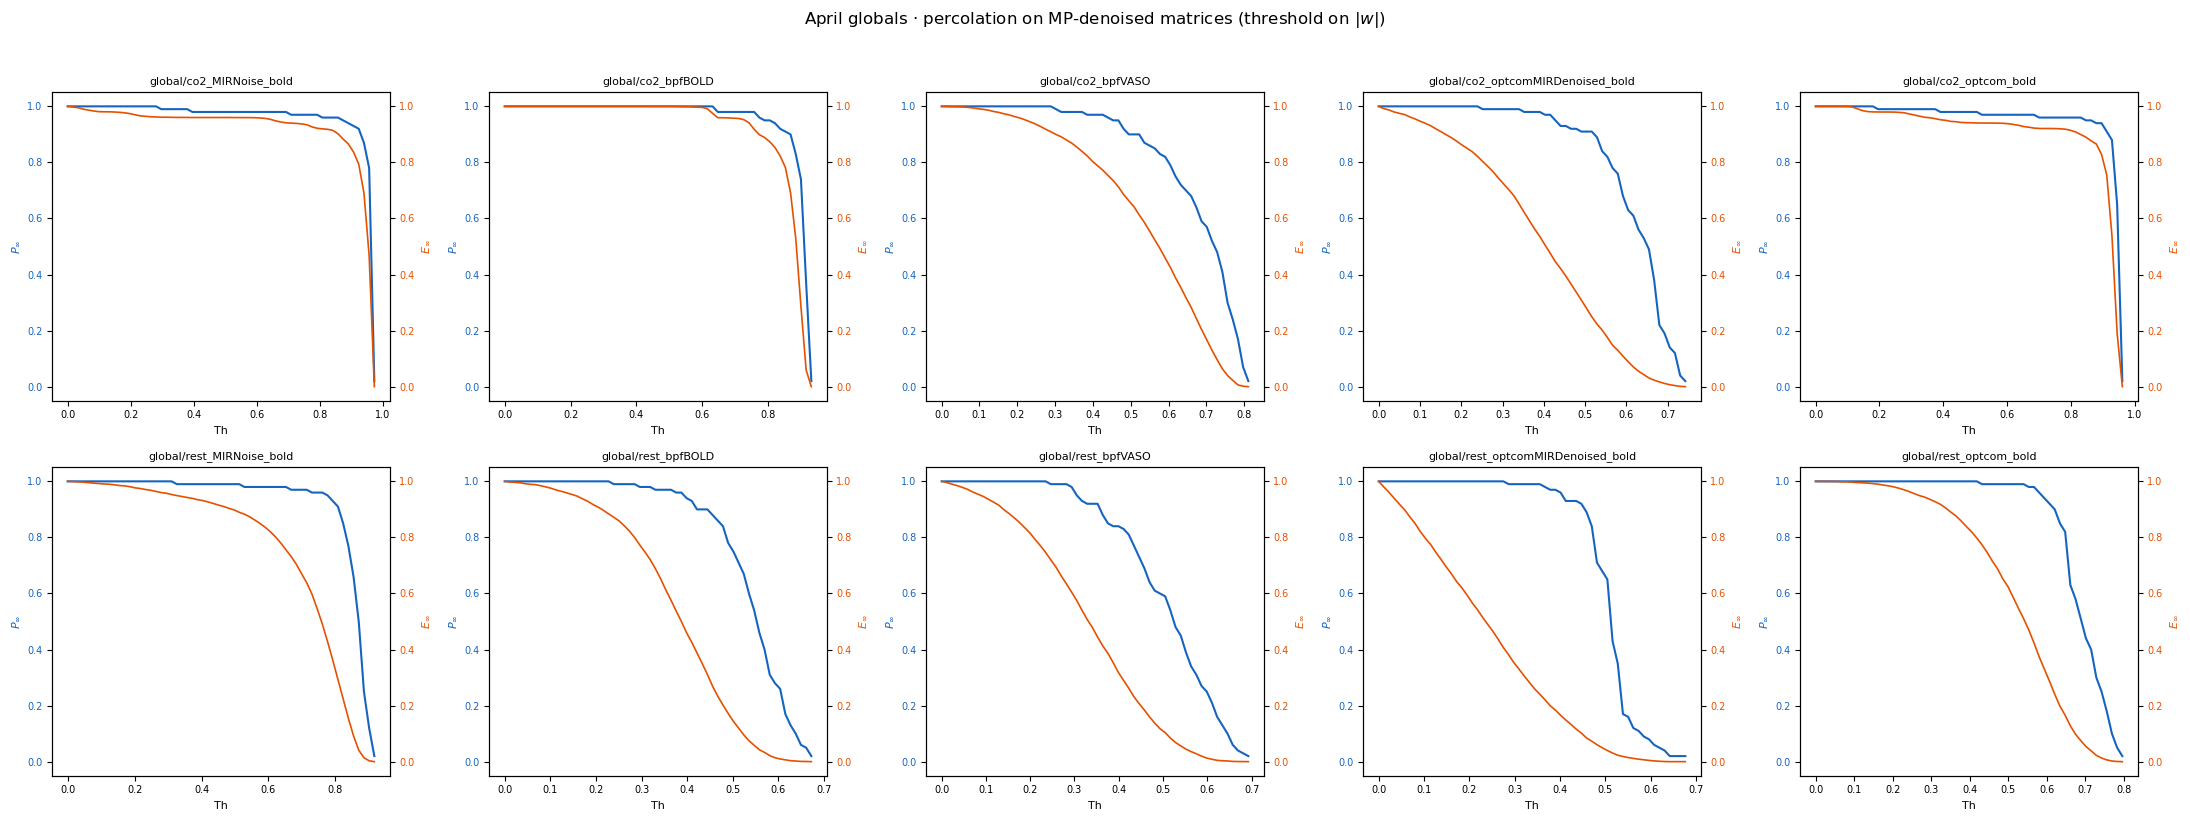

In [6]:
fig, axes = plt.subplots(*GRID, figsize=(22, 8), squeeze=False)
for ax, (label, rec) in zip(axes.ravel(), globals_data.items()):
    plot_percolation_curve(
        rec["corr_mp"], ax=ax, title=label, n_thresholds=60, compact=True
    )
fig.suptitle(
    "April globals · percolation on MP-denoised matrices (threshold on $|w|$)",
    y=1.02,
)
fig.tight_layout()
plt.show()

## 6. Network drawings — strongest connections (MP-cleaned)

For each global matrix, draw the network restricted to the top 5 % of
edges by $|w_{ij}|$ on the MP-cleaned matrix. Edge colour encodes sign
(blue: positive, red: negative); edge width scales with $|w|^{2}$ so
heterogeneity is visually exaggerated. Node size scales with retained
strength $s_i = \sum_{j\in\mathcal{E}_{\text{top}}} |w_{ij}|$. Spring
layout with a fixed seed for reproducibility.

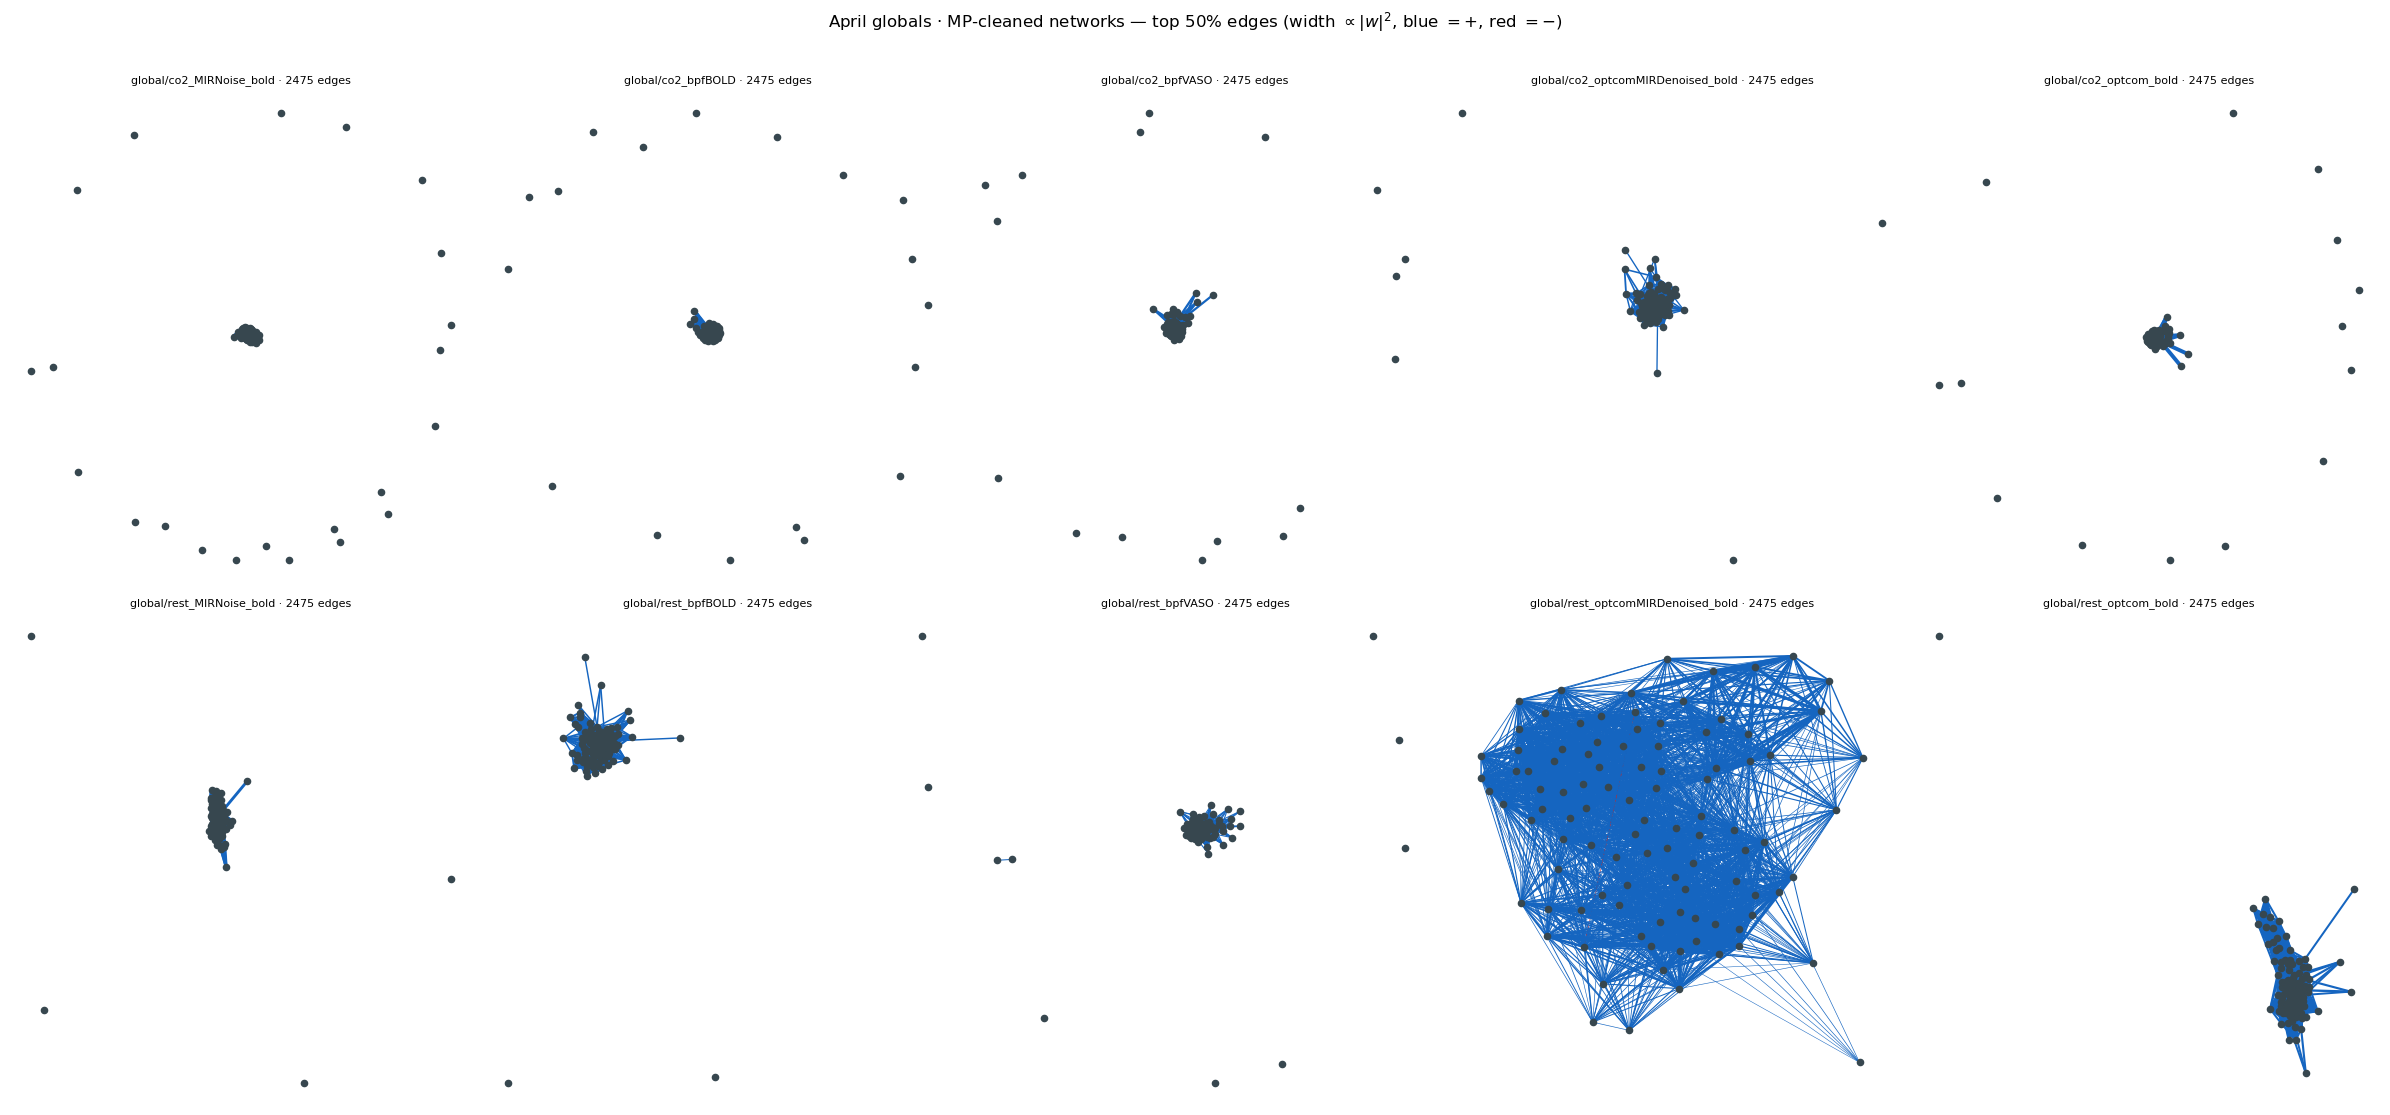

In [7]:
TOP_FRACTION = 0.50

fig, axes = plt.subplots(*GRID, figsize=(24, 11), squeeze=False)
for ax, (label, rec) in zip(axes.ravel(), globals_data.items()):
    C = rec["corr_mp"]
    thr = np.quantile(np.abs(C[np.triu_indices_from(C, k=1)]), 1 - TOP_FRACTION)
    G = nx.from_numpy_array(np.where(np.abs(C) >= thr, C, 0.0))
    w = np.array([d["weight"] for _, _, d in G.edges(data=True)])
    nx.draw(
        G, pos=nx.spring_layout(G, seed=0), ax=ax,
        node_size=20, node_color="#37474F",
        edge_color=np.where(w > 0, "#1565C0", "#C62828").tolist(),
        width=(np.abs(w) / np.abs(w).max()) ** 2 * 3.0,
    )
    ax.set_title(f"{label} · {G.number_of_edges()} edges", fontsize=8)
fig.suptitle(
    f"April globals · MP-cleaned networks — top {int(TOP_FRACTION*100)}% edges "
    "(width $\\propto |w|^2$, blue $=+$, red $=-$)",
    y=1.01,
)
fig.tight_layout()
plt.show()

## 7. Global-baseline removal (verification)

Subtract the per-matrix off-diagonal mean,
$\tilde{C}_{ij} = C_{ij} - \langle C \rangle_{i\neq j}$, and re-plot the
heatmaps. If the structure observed up to here is dominated by a single
global eigenmode (missing global-signal regression or non-demeaned
time-series upstream), the residual $\tilde C$ should reveal block /
modular patterns; if not, the matrices are genuinely close to rank-1
plus noise. The printed table reports $\langle C \rangle_{\mathrm{off}}$,
the residual standard deviation, and the fraction of off-diagonal
entries that turn negative after removal.

label                                   mean_off  std_resid  frac_neg
global/co2_MIRNoise_bold                  +0.923      0.182     15.9%
global/co2_bpfBOLD                        +0.884      0.072     30.0%
global/co2_bpfVASO                        +0.555      0.198     42.2%
global/co2_optcomMIRDenoised_bold         +0.401      0.209     47.2%
global/co2_optcom_bold                    +0.901      0.168     15.8%
global/rest_MIRNoise_bold                 +0.726      0.183     36.4%
global/rest_bpfBOLD                       +0.393      0.154     48.1%
global/rest_bpfVASO                       +0.342      0.170     49.7%
global/rest_optcomMIRDenoised_bold        +0.254      0.191     53.3%
global/rest_optcom_bold                   +0.539      0.159     46.6%


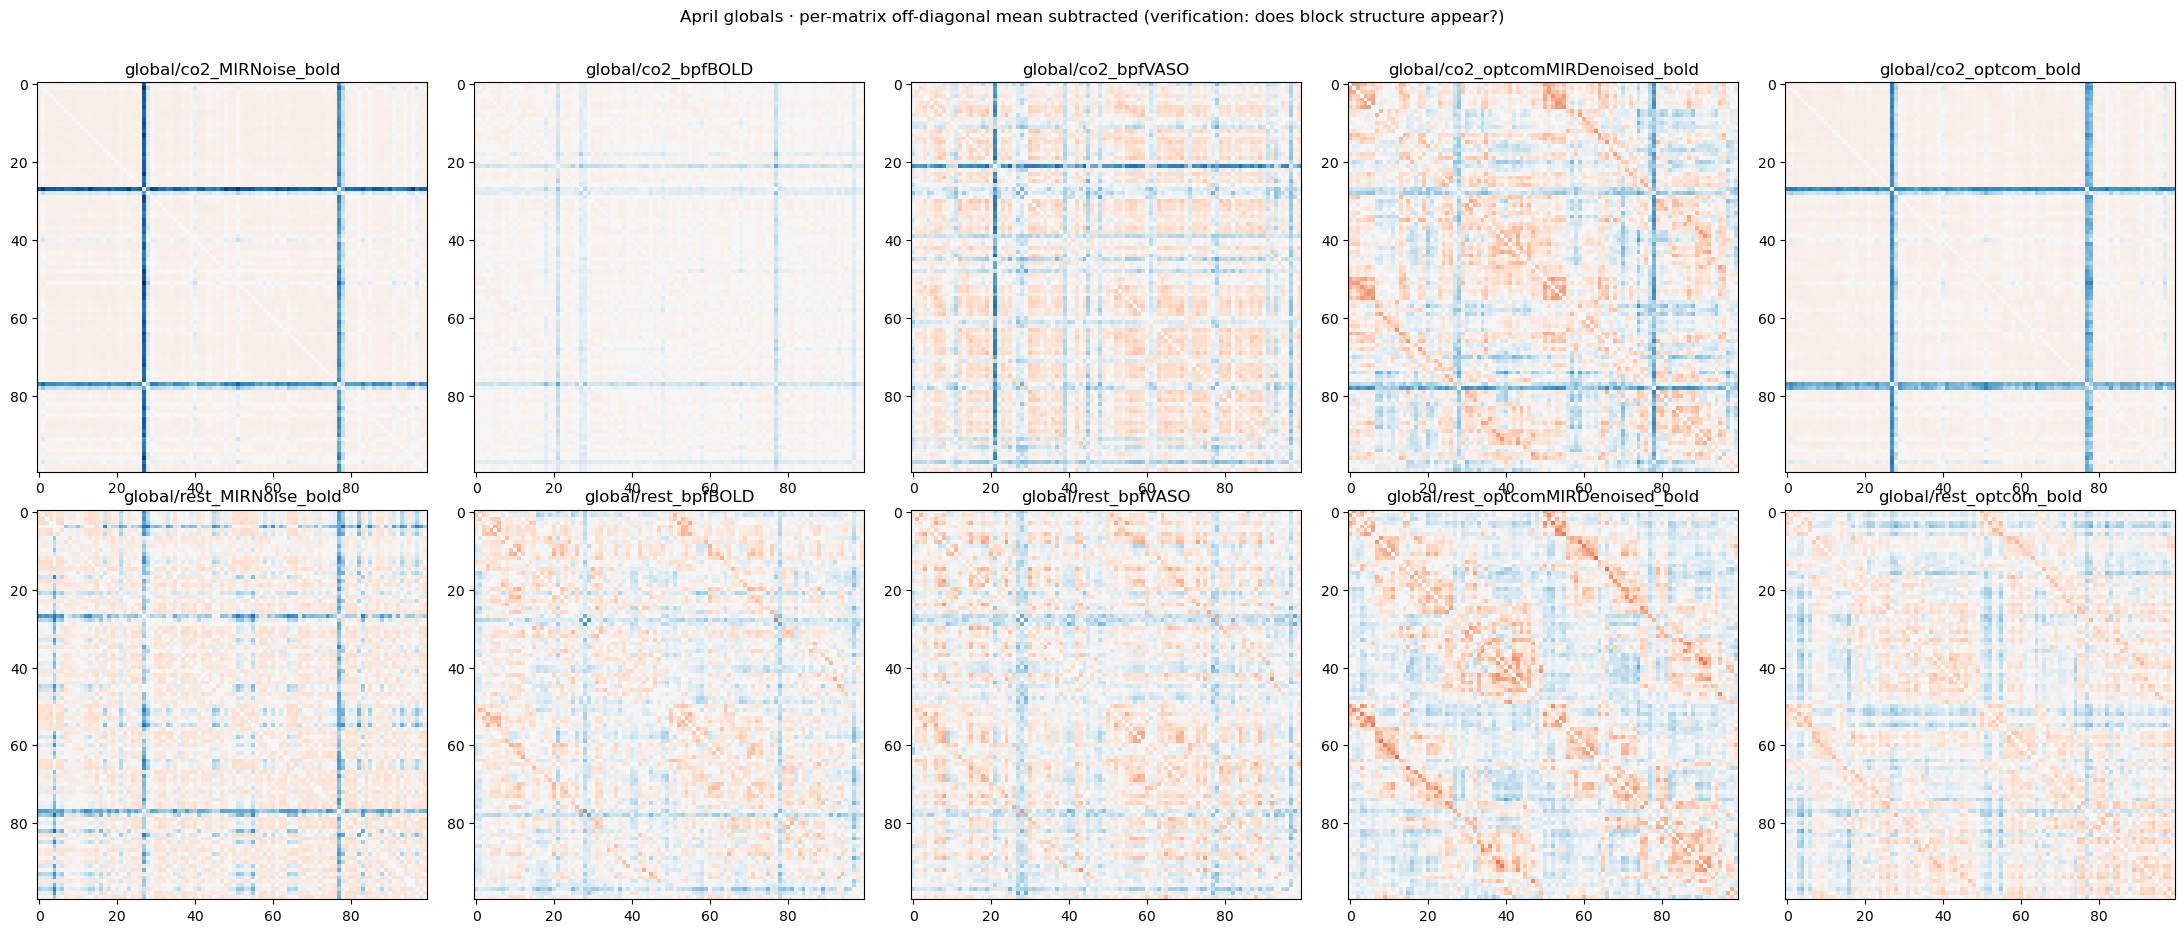

In [8]:
mats = {}
print(f"{'label':36s}  {'mean_off':>10s} {'std_resid':>10s} {'frac_neg':>9s}")
for label, rec in globals_data.items():
    C = rec["corr"]
    triu = np.triu_indices_from(C, k=1)
    mu = float(C[triu].mean())
    Ct = C - mu
    np.fill_diagonal(Ct, 0.0)
    mats[label] = Ct
    off = Ct[triu]
    print(f"{label:36s}  {mu:+10.3f} {off.std():10.3f} {(off < 0).mean() * 100:8.1f}%")

vmax_bl = float(max(np.abs(M).max() for M in mats.values()))
fig, axes = plt.subplots(*GRID, figsize=(22, 9), squeeze=False)
for ax, (label, M) in zip(axes.ravel(), mats.items()):
    plot_correlation_matrix(M, ax=ax, title=label, vmax=vmax_bl, colorbar=False)
fig.suptitle(
    "April globals · per-matrix off-diagonal mean subtracted "
    "(verification: does block structure appear?)",
    y=1.02,
)
fig.tight_layout()
plt.show()